In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pyref.fitting as fit

from utils import models_root
from utils.helpers.plotting_helper import set_plotting_defaults

set_plotting_defaults()

In [2]:
with open(models_root / "xrr/znpc/dft/dft_en_offset_new2.pkl", "rb") as f:
    dft_constraint = pickle.load(f)
with open(models_root / "xrr/znpc/free/free_en_offset_init_2.pkl", "rb") as f:
    exp_constrained = pickle.load(f)
# Identify the objective with the 283.7 energy
ens = [o.model.energy for o in dft_constraint.objectives]
target = np.argmin(np.abs(np.array(ens) - 283.7))
single_energy_dft = dft_constraint.objectives[target]
single_energy_exp = exp_constrained.objectives[target]

# Global target parameters
energy_offset = single_energy_dft.model.energy_offset
interface_thickness = single_energy_dft.model.structure[3].thick
interface_roughness = single_energy_dft.model.structure[3].rough
interface_density = single_energy_dft.model.structure[3].sld.density
# Derived value
interface_width = np.sqrt(2*np.pi) * interface_roughness
interface_bulk_ratio = interface_width / interface_thickness
print(f"energy_offset: {energy_offset}")
print(f"interface_bulk_ratio: {interface_bulk_ratio}")
print(f"interface_width: {interface_width}")
print(f"interface_thickness: {interface_thickness}")
print(f"interface_roughness: {interface_roughness}")
print(f"interface_density: {interface_density}")

energy_offset: <Parameter:'energy_offset', value=0.00349378 +/- 1.99e-06, bounds=[-0.5, 0.5]>
interface_bulk_ratio: <Parameter:     None      , value=1.84809  (fixed) , bounds=None>
interface_width: <Parameter:     None      , value=19.7834  (fixed) , bounds=None>
interface_thickness: <Parameter:'Contamination_283.7_thick', value=10.7048 +/- 0.00311, bounds=[0.0, 35.0]>
interface_roughness: <Parameter:'Contamination_283.7_rough', value=7.89243 +/- 0.000519, bounds=[0.0, 25.0]>
interface_density: <Parameter:'Contamination_283.7_density', value=1.8 +/- 0.332, bounds=[1.0, 1.8]>


In [3]:
for i, slab in enumerate(single_energy_dft.model.structure):
    if i not in [0, len(single_energy_dft.model.structure) - 1]:
        slab.thick.setp(vary=True)
        slab.rough.setp(vary=True)

In [4]:
# Fit the structure on just the single energy to look at what the parameters look like
single_energy_fitter_dft = fit.CurveFitter(single_energy_dft)
single_energy_fitter_exp = fit.CurveFitter(single_energy_exp)
single_energy_fitter_dft.fit(options={"worker":-1})
single_energy_fitter_exp.fit(options={"worker":-1})

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/refnx/analysis/curvefitter.py:847: OptimizeWarning: Unknown solver options: worker
  res = minimize(cost, init_pars, **_min_kws)
-0.9751014927919301: : 636it [02:10,  4.87it/s]
0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/pyref/fitting/uniaxial.py:175: UserWarning: Reflection coefficients exceed 1, clipping to 1.
  refl, tran = calculate_output(numpnts, M)
-0.8595539022892845: : 45it [00:09,  4.63it/s] 


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -0.8595539022892845
        x: [ 1.100e+00  9.000e-01 ...  2.100e+00  2.400e+00]
      nit: 45
      jac: [-2.480e-01  4.678e-01 ...  1.473e-01  1.825e-01]
     nfev: 969
     njev: 51
 hess_inv: <18x18 LbfgsInvHessProduct with dtype=float64>
    covar: [[ 2.257e-03  1.362e-03 ... -2.177e-03 -5.927e-04]
            [ 1.362e-03  1.612e-03 ... -3.227e-03 -4.200e-04]
            ...
            [-2.177e-03 -3.227e-03 ...  2.454e-02  1.094e-04]
            [-5.927e-04 -4.200e-04 ...  1.094e-04  1.187e-03]]
   stderr: [ 4.751e-02  4.015e-02 ...  1.567e-01  3.445e-02]

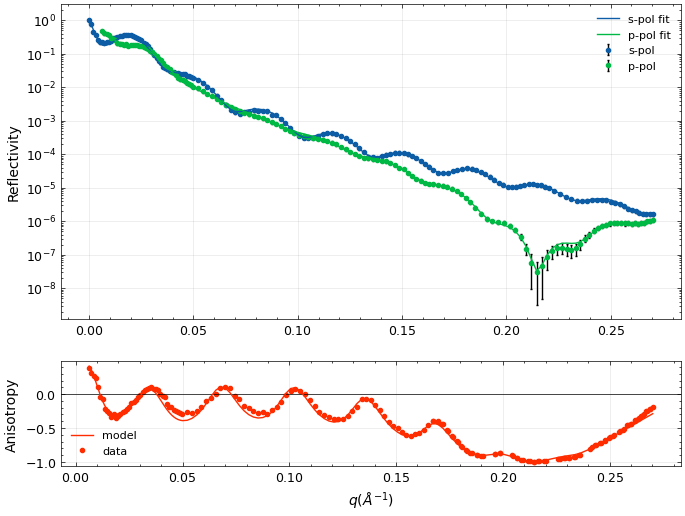

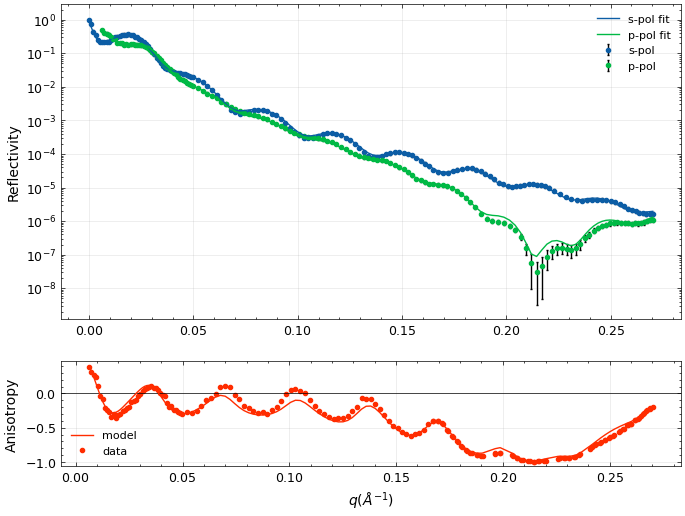

In [6]:
single_energy_fitter_dft.objective.plot()
plt.show()
single_energy_fitter_exp.objective.plot()
plt.show()

<Axes: >

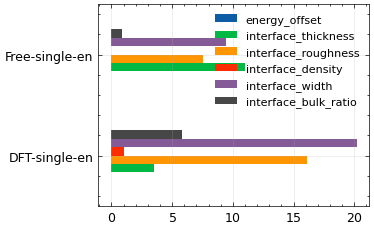

In [7]:
import pandas as pd

def important_params(model, name: str):
    # Global target parameters
    energy_offset = model.energy_offset
    interface_thickness = model.structure[3].thick
    interface_roughness = model.structure[3].rough
    interface_density = model.structure[3].sld.density
    # Derived value
    interface_width = np.sqrt(2*np.pi) * interface_roughness / 2
    interface_bulk_ratio = interface_width / interface_thickness
    return pd.DataFrame({
        "energy_offset": energy_offset.value,
        "interface_thickness": interface_thickness.value,
        "interface_roughness": interface_roughness.value,
        "interface_density": interface_density.value,
        "interface_width": interface_width.value,
        "interface_bulk_ratio": interface_bulk_ratio.value,
    }, index=[name])

df = important_params(single_energy_dft.model, "DFT-single-en")
df = pd.concat([df, important_params(single_energy_exp.model, "Free-single-en")])
# Plot as horizontal bar chart with parameter names along y-axis
df.plot.barh()

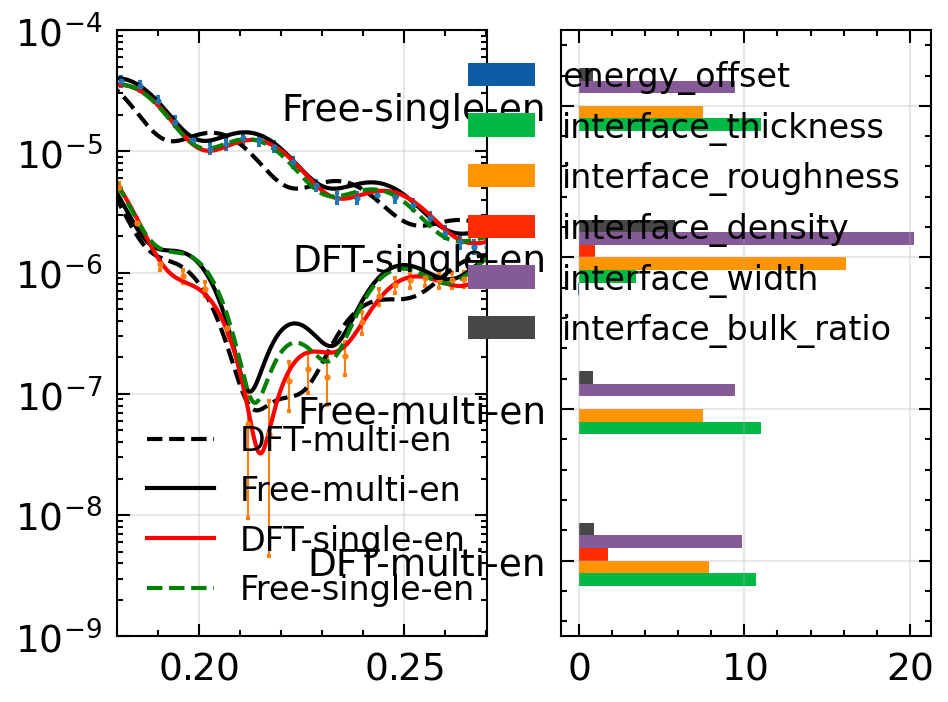

In [8]:
#load back in the multi-en fit
with open(models_root / "xrr/znpc/dft/dft_en_offset_new2.pkl", "rb") as f:
    dft_multi_en = pickle.load(f)

with open(models_root / "xrr/znpc/free/free_en_offset_init_2.pkl", "rb") as f:
    exp_multi_en = pickle.load(f)

fig, ax = plt.subplots(ncols = 2, dpi = 300)
# Setup cmap
cmap = plt.get_cmap("tab10")
# Plot the data
data = single_energy_fitter_dft.objective.data
max_q = data.s.x[-1]
for pol in ["s", "p"]:
    color = cmap(0) if pol == "s" else cmap(1)
    pol_data = getattr(data, pol)
    ax[0].errorbar(
        pol_data.x,
        pol_data.y,
        yerr=pol_data.y_err,
        lw=0,
        color=color,
        capsize=.5,
        # ecolor="k",
        marker="o",
        elinewidth=.5,
        markersize=.5,
        markerfacecolor=color,
        markevery=2,
        errorevery=2,
    )

q = np.linspace(0.001, max_q, 1000)
model_list = [
    {"name": "DFT-multi-en", "model": dft_multi_en.objectives[target].model, "color": "k", "ls": "--"},
    {"name": "Free-multi-en", "model": exp_multi_en.objectives[target].model, "color": "k", "ls": "-"},
    {"name": "DFT-single-en", "model": single_energy_fitter_dft.objective.model, "color": "r", "ls": "-"},
    {"name": "Free-single-en", "model": single_energy_fitter_exp.objective.model, "color": "g", "ls": "--"},
]
dfs = []
for model in model_list:
    dfs.append(important_params(model["model"], model["name"]))
    model["model"].pol="s"
    ax[0].plot(
        q,
        model["model"](q),
        color=model["color"],
        label=model["name"],
        ls=model["ls"]
    )
    model["model"].pol="p"
    ax[0].plot(
        q,
        model["model"](q),
        color=model["color"],
        ls=model["ls"]
    )
    model["model"].pol="sp"
ax[0].set_xlim(.18, data.s.x[-1])
ax[0].set_ylim(1e-9,1e-4)
ax[0].set_yscale("log")
ax[0].legend()

df = pd.concat(dfs)
df.plot.barh(ax = ax[1])
plt.show()

/tmp/ipykernel_114757/1390548084.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


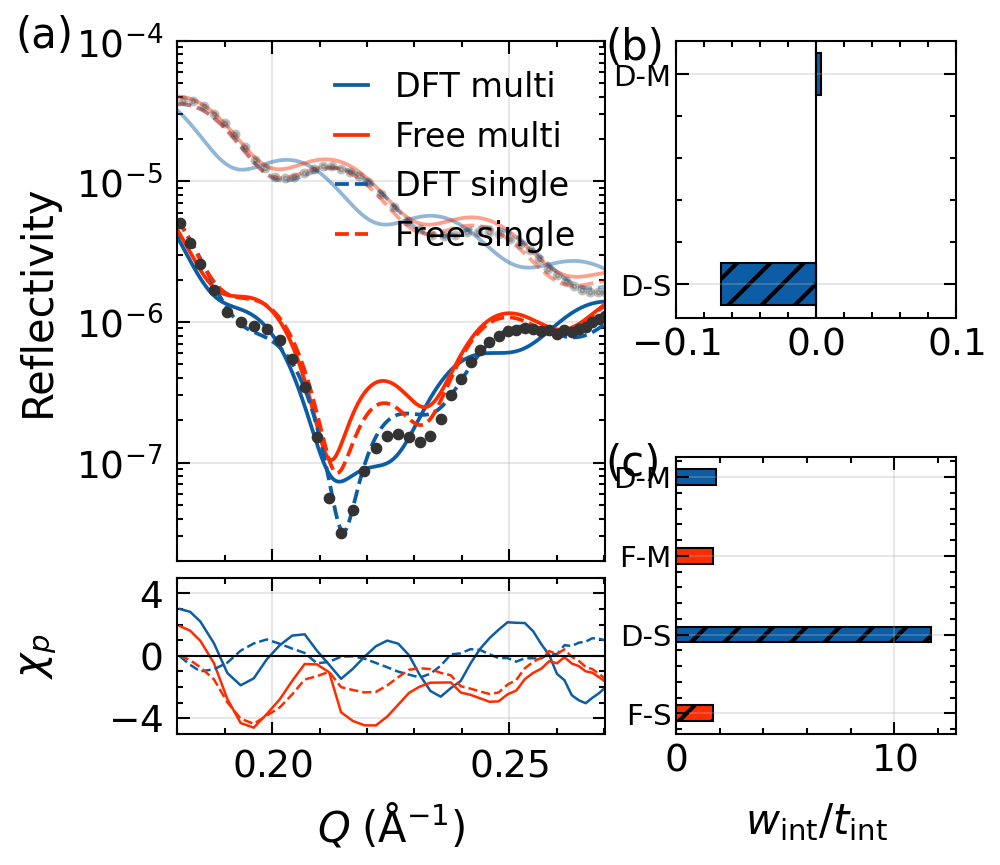

In [53]:
"""Brewster-region diagnostic figure for ZnPc fits, PRL single-column.

Three coordinated panels in a 3.35 by 4.5 inch frame.

Panel (a) zooms on the Brewster minimum and overlays all four candidate
models with a tightly coupled normalized-residual strip below.

Panel (b) compares the energy offset of the two DFT-anchored fits. The
shaded band is the monochromator calibration window. The Free models are
omitted because their energy offset is not chemically constrained.

Panel (c) shows the interface width to thickness ratio for all four models.
A vertical line at 1.0 and a tinted region above mark the regime where the
Nevot-Croce roughness approximation no longer applies.

The script assumes dft_multi_en, exp_multi_en, single_energy_fitter_dft,
single_energy_fitter_exp and target are already in scope.
"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# Color encodes electronic-structure choice. Linestyle and hatching encode
# energy treatment. This keeps the 8 plotted curves visually distinct under
# only two color slots.
# ---------------------------------------------------------------------------
COLOR_DFT = "C0"
COLOR_FREE = "C3"

MODELS = [
    {
        "name": "DFT multi",  "short": "D-M",
        "model": dft_multi_en.objectives[target].model,
        "color": COLOR_DFT, "ls": "-", "hatch": "",
    },
    {
        "name": "Free multi", "short": "F-M",
        "model": exp_multi_en.objectives[target].model,
        "color": COLOR_FREE, "ls": "-", "hatch": "",
    },
    {
        "name": "DFT single", "short": "D-S",
        "model": single_energy_fitter_dft.objective.model,
        "color": COLOR_DFT, "ls": "--", "hatch": "///",
    },
    {
        "name": "Free single", "short": "F-S",
        "model": single_energy_fitter_exp.objective.model,
        "color": COLOR_FREE, "ls": "--", "hatch": "///",
    },
]


def extract_diagnostics(model):
    eo = model.energy_offset.value
    th = model.structure[3].thick.value
    ro = model.structure[3].rough.value
    width = np.sqrt(2.0 * np.pi) * ro
    return eo, width / th


diag = [extract_diagnostics(m["model"]) for m in MODELS]
eo_vals = np.array([d[0] for d in diag])
wt_vals = np.array([d[1] for d in diag])

# ---------------------------------------------------------------------------
# Nested gridspec. Outer grid is two columns. The left column carries the
# reflectivity panel and its tightly coupled residual strip. The right column
# carries the two diagnostic bar panels stacked vertically. The figure as a
# whole still fits in a PRL single-column width.
# ---------------------------------------------------------------------------
fig_width, fig_height = 3.35, 3
fig = plt.figure(figsize=(fig_width, fig_height), dpi=300)

gs_outer = fig.add_gridspec(
    nrows=1, ncols=2,
    width_ratios=[1.6, 1.05],
    wspace=0.2,
)
gs_left = gs_outer[0].subgridspec(
    nrows=2, ncols=1,
    height_ratios=[3.0, 0.9],
    hspace=0.05,
)
gs_right = gs_outer[1].subgridspec(
    nrows=2, ncols=1,
    hspace=0.5,
)

ax_R = fig.add_subplot(gs_left[0])
ax_res = fig.add_subplot(gs_left[1], sharex=ax_R)
ax_eo = fig.add_subplot(gs_right[0])
ax_wt = fig.add_subplot(gs_right[1])

# ---------------------------------------------------------------------------
# Panel (a): Brewster-region reflectivity, both polarizations.
# ---------------------------------------------------------------------------
data = single_energy_fitter_dft.objective.data
qmin, qmax = 0.18, float(data.s.x[-1])
q_grid = np.linspace(qmin, qmax, 1024)

for pol, alpha_pts, ms in (("s", 0.30, 1.4), ("p", 1.00, 1.8)):
    d = getattr(data, pol)
    mask = (d.x >= qmin) & (d.x <= qmax)
    ax_R.errorbar(
        d.x[mask], d.y[mask], yerr=d.y_err[mask],
        lw=0, marker="o", markersize=ms, capsize=0,
        color="0.20", alpha=alpha_pts, errorevery=2,
    )

for m in MODELS:
    mod = m["model"]
    for pol in ("s", "p"):
        mod.pol = pol
        alpha_curve = 0.45 if pol == "s" else 1.0
        ax_R.plot(
            q_grid, mod(q_grid),
            color=m["color"], ls=m["ls"], lw=0.9,
            alpha=alpha_curve,
            label=m["name"] if pol == "p" else None,
        )
        d = getattr(data, pol)
        mask = (d.x >= qmin) & (d.x <= qmax)
        chi = (d.y[mask] - mod(d.x[mask])) / d.y_err[mask]
        if pol == "p":
            ax_res.plot(
                d.x[mask], chi,
                color=m["color"], ls=m["ls"], lw=0.6,
            )
    mod.pol = "sp"

ax_R.set_yscale("log")
ax_R.set_xlim(qmin, qmax)
ax_R.set_ylim(2e-8, 1e-4)
ax_R.set_ylabel("Reflectivity")
ax_R.tick_params(labelbottom=False)
ax_R.minorticks_on()
ax_R.legend(
    loc="upper right", handlelength=1,
)

ax_res.axhline(0.0, color=plt.rcParams["axes.edgecolor"], lw=plt.rcParams["axes.linewidth"])
ax_res.set_ylim(-5, 5)
ax_res.set_yticks([-4, 0, 4])
ax_res.set_ylabel(r"$\chi_p$")
ax_res.set_xlabel(r"$Q\;(\mathrm{\AA^{-1}})$")
ax_res.minorticks_on()

# ---------------------------------------------------------------------------
# Panel (b): energy offset for DFT models only. The shaded band is the
# beamline calibration window. Replace CAL_HALF_WIDTH with the actual
# calibration uncertainty.
# ---------------------------------------------------------------------------
CAL_HALF_WIDTH = 0.15  # eV
dft_models = [m for m in MODELS if "DFT" in m["name"]]
dft_eo = [eo_vals[i] for i, m in enumerate(MODELS) if "DFT" in m["name"]]
dft_labels = [m["short"] for m in dft_models]
dft_hatches = [m["hatch"] for m in dft_models]


ax_eo.axvline(0.0, color=plt.rcParams["axes.edgecolor"], lw=plt.rcParams["axes.linewidth"])
bars_eo = ax_eo.barh(
    np.arange(len(dft_eo)), dft_eo,
    color=COLOR_DFT, edgecolor="k", linewidth=0.5, height=0.2,
)
for bar, h in zip(bars_eo, dft_hatches):
    bar.set_hatch(h)
ax_eo.set_yticks(np.arange(len(dft_eo)))
ax_eo.set_yticklabels(dft_labels, fontsize=7)
ax_eo.invert_yaxis()
ax_eo.set_xlabel(r"$\Delta E$ (eV)")
ax_eo.set_xlim(-0.1, 0.1)
ax_eo.tick_params(axis="x", pad=2)
ax_eo.tick_params(axis="y", pad=1)
ax_eo.minorticks_on()

# ---------------------------------------------------------------------------
# Panel (c): width to thickness ratio for all four models.
# ---------------------------------------------------------------------------
xmax_wt = max(2.0, wt_vals.max() * 1.10)
bars_wt = ax_wt.barh(
    np.arange(len(MODELS)), wt_vals,
    color=[m["color"] for m in MODELS],
    edgecolor="k", linewidth=0.5, height=0.2,
)
for bar, m in zip(bars_wt, MODELS):
    bar.set_hatch(m["hatch"])
ax_wt.set_yticks(np.arange(len(MODELS)))
ax_wt.set_yticklabels([m["short"] for m in MODELS], fontsize=7)
ax_wt.invert_yaxis()
ax_wt.set_xlim(0, xmax_wt)
ax_wt.set_xlabel(r"$w_\mathrm{int}/t_\mathrm{int}$")
ax_wt.tick_params(axis="x", pad=2)
ax_wt.tick_params(axis="y", pad=1)
ax_wt.minorticks_on()

# ---------------------------------------------------------------------------
# Panel labels. Panel (a) follows the PRL gutter convention. Panels (b) and
# (c) are too narrow for that placement to clear the y-tick labels, so they
# sit above the axes instead.
# ---------------------------------------------------------------------------
ax_R.text(
    -0.38, 1.05, "(a)", transform=ax_R.transAxes, va="top", ha="left",
)
for ax, tag in ((ax_eo, "(b)"), (ax_wt, "(c)")):
    ax.text(
        -0.25, 1.05, tag, transform=ax.transAxes, va="top", ha="left",
    )

fig.align_labels()
fig.tight_layout()
fig.savefig(
    "brewster_diagnostic_figure.png",
    dpi=300, bbox_inches="tight", transparent=True,
)
plt.show()

/tmp/ipykernel_114757/2638243643.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


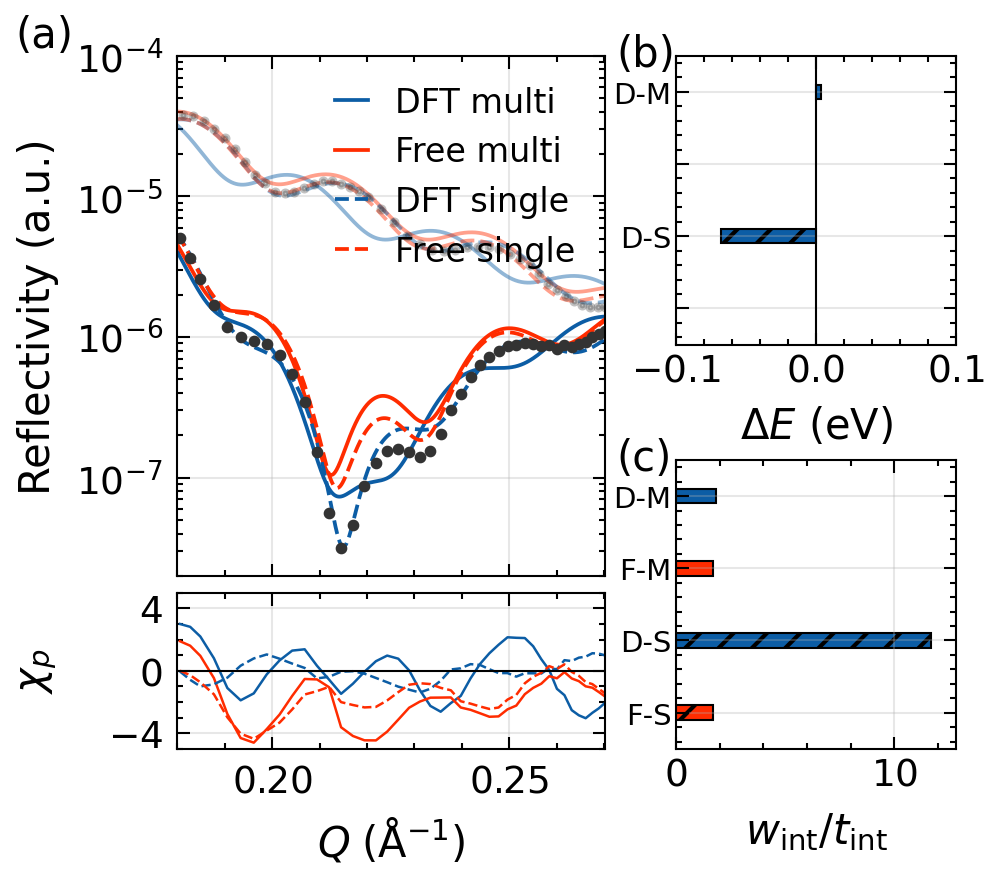

In [70]:
"""Brewster-region diagnostic figure for ZnPc fits, PRL single-column.

Three coordinated panels in a 3.35 by 3.0 inch frame.

Panel (a) zooms on the Brewster minimum and overlays all four candidate
models with a tightly coupled normalized-residual strip below.

Panel (b) compares the energy offset of the two DFT-anchored fits. The
Free models are omitted because their energy offset is not chemically
constrained, but their row slots are kept so that the bars align with the
corresponding rows in panel (c).

Panel (c) shows the interface width to thickness ratio for all four models.

The script assumes dft_multi_en, exp_multi_en, single_energy_fitter_dft,
single_energy_fitter_exp and target are already in scope.
"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# Color encodes electronic-structure choice. Linestyle and hatching encode
# energy treatment. This keeps the 8 plotted curves visually distinct under
# only two color slots.
# ---------------------------------------------------------------------------
COLOR_DFT = "C0"
COLOR_FREE = "C3"

MODELS = [
    {
        "name": "DFT multi",  "short": "D-M",
        "model": dft_multi_en.objectives[target].model,
        "color": COLOR_DFT, "ls": "-", "hatch": "",
    },
    {
        "name": "Free multi", "short": "F-M",
        "model": exp_multi_en.objectives[target].model,
        "color": COLOR_FREE, "ls": "-", "hatch": "",
    },
    {
        "name": "DFT single", "short": "D-S",
        "model": single_energy_fitter_dft.objective.model,
        "color": COLOR_DFT, "ls": "--", "hatch": "///",
    },
    {
        "name": "Free single", "short": "F-S",
        "model": single_energy_fitter_exp.objective.model,
        "color": COLOR_FREE, "ls": "--", "hatch": "///",
    },
]


def extract_diagnostics(model):
    eo = model.energy_offset.value
    th = model.structure[3].thick.value
    ro = model.structure[3].rough.value
    width = np.sqrt(2.0 * np.pi) * ro
    return eo, width / th


diag = [extract_diagnostics(m["model"]) for m in MODELS]
eo_vals = np.array([d[0] for d in diag])
wt_vals = np.array([d[1] for d in diag])

# ---------------------------------------------------------------------------
# Nested gridspec. Outer grid is two columns. The left column carries the
# reflectivity panel and its tightly coupled residual strip. The right column
# carries the two diagnostic bar panels stacked vertically. The figure as a
# whole still fits in a PRL single-column width.
# ---------------------------------------------------------------------------
fig_width, fig_height = 3.35, 3.0
fig = plt.figure(figsize=(fig_width, fig_height), dpi=300)

gs_outer = fig.add_gridspec(
    nrows=1, ncols=2,
    width_ratios=[1.6, 1.05],
    wspace=0.2,
)
gs_left = gs_outer[0].subgridspec(
    nrows=2, ncols=1,
    height_ratios=[3.0, 0.9],
    hspace=0.05,
)
gs_right = gs_outer[1].subgridspec(
    nrows=2, ncols=1,
    hspace=0.4,
)

ax_R = fig.add_subplot(gs_left[0])
ax_res = fig.add_subplot(gs_left[1], sharex=ax_R)
ax_eo = fig.add_subplot(gs_right[0])
ax_wt = fig.add_subplot(gs_right[1])

# ---------------------------------------------------------------------------
# Panel (a): Brewster-region reflectivity, both polarizations.
# ---------------------------------------------------------------------------
data = single_energy_fitter_dft.objective.data
qmin, qmax = 0.18, float(data.s.x[-1])
q_grid = np.linspace(qmin, qmax, 1024)

for pol, alpha_pts, ms in (("s", 0.30, 1.4), ("p", 1.00, 1.8)):
    d = getattr(data, pol)
    mask = (d.x >= qmin) & (d.x <= qmax)
    ax_R.errorbar(
        d.x[mask], d.y[mask], yerr=d.y_err[mask],
        lw=0, marker="o", markersize=ms, capsize=0,
        color="0.20", alpha=alpha_pts, errorevery=2,
    )

for m in MODELS:
    mod = m["model"]
    for pol in ("s", "p"):
        mod.pol = pol
        alpha_curve = 0.45 if pol == "s" else 1.0
        ax_R.plot(
            q_grid, mod(q_grid),
            color=m["color"], ls=m["ls"], lw=0.9,
            alpha=alpha_curve,
            label=m["name"] if pol == "p" else None,
        )
        d = getattr(data, pol)
        mask = (d.x >= qmin) & (d.x <= qmax)
        chi = (d.y[mask] - mod(d.x[mask])) / d.y_err[mask]
        if pol == "p":
            ax_res.plot(
                d.x[mask], chi,
                color=m["color"], ls=m["ls"], lw=0.6,
            )
    mod.pol = "sp"

ax_R.set_yscale("log")
ax_R.set_xlim(qmin, qmax)
ax_R.set_ylim(2e-8, 1e-4)
ax_R.set_ylabel("Reflectivity (a.u.)")
ax_R.tick_params(labelbottom=False)
ax_R.minorticks_on()
ax_R.legend(
    loc="upper right", handlelength=1,
)

ax_res.axhline(
    0.0,
    color=plt.rcParams["axes.edgecolor"],
    lw=plt.rcParams["axes.linewidth"],
)
ax_res.set_ylim(-5, 5)
ax_res.set_yticks([-4, 0, 4])
ax_res.set_ylabel(r"$\chi_p$")
ax_res.set_xlabel(r"$Q\;(\mathrm{\AA^{-1}})$")
ax_res.minorticks_on()

# ---------------------------------------------------------------------------
# Panel (b): energy offset, DFT models only. The DFT bars are placed at
# their native indices in MODELS so that D-M and D-S in (b) sit directly
# above their counterparts in (c). The Free rows in (b) are deliberately
# left blank to read as "this metric is not chemically defined for the
# free tensor models." The shared y-axis configuration also forces the
# left edge of (b) to align with the left edge of (c).
# ---------------------------------------------------------------------------
dft_idx = [i for i, m in enumerate(MODELS) if "DFT" in m["name"]]
dft_eo_vals = [eo_vals[i] for i in dft_idx]
dft_hatches = [MODELS[i]["hatch"] for i in dft_idx]

ax_eo.axvline(
    0.0,
    color=plt.rcParams["axes.edgecolor"],
    lw=plt.rcParams["axes.linewidth"],
)
bars_eo = ax_eo.barh(
    dft_idx, dft_eo_vals,
    color=COLOR_DFT, edgecolor="k", linewidth=0.5, height=0.2,
)
for bar, h in zip(bars_eo, dft_hatches):
    bar.set_hatch(h)

ax_eo.set_yticks(np.arange(len(MODELS)))
ax_eo.set_yticklabels(
    [m["short"] if "DFT" in m["name"] else "" for m in MODELS],
    fontsize=7,
)
ax_eo.set_ylim(len(MODELS) - 0.5, -0.5)
ax_eo.set_xlim(-0.1, 0.1)
ax_eo.set_xlabel(r"$\Delta E$ (eV)")
ax_eo.tick_params(axis="x", pad=2)
ax_eo.tick_params(axis="y", pad=1)
ax_eo.minorticks_on()

# ---------------------------------------------------------------------------
# Panel (c): width to thickness ratio for all four models. Shares y-axis
# configuration with panel (b).
# ---------------------------------------------------------------------------
xmax_wt = max(2.0, wt_vals.max() * 1.10)
bars_wt = ax_wt.barh(
    np.arange(len(MODELS)), wt_vals,
    color=[m["color"] for m in MODELS],
    edgecolor="k", linewidth=0.5, height=0.2,
)
for bar, m in zip(bars_wt, MODELS):
    bar.set_hatch(m["hatch"])

ax_wt.set_yticks(np.arange(len(MODELS)))
ax_wt.set_yticklabels([m["short"] for m in MODELS], fontsize=7)
ax_wt.set_ylim(len(MODELS) - 0.5, -0.5)
ax_wt.set_xlim(0, xmax_wt)
ax_wt.set_xlabel(r"$w_\mathrm{int}/t_\mathrm{int}$")
ax_wt.tick_params(axis="x", pad=2)
ax_wt.tick_params(axis="y", pad=1)
ax_wt.minorticks_on()

# ---------------------------------------------------------------------------
# Panel labels. Panel (a) follows the PRL gutter convention. Panels (b) and
# (c) sit above the axes because the narrow right column will not clear the
# y-tick labels with the gutter placement.
# ---------------------------------------------------------------------------
# Panel (a) keeps the PRL gutter convention because it has a y-axis label
# to align against and a tall panel that can absorb the offset. Panels (b)
# and (c) place their labels inside the axes at the top-left corner. This
# keeps them clear of the tight-bbox cropping that was clipping panel (b)'s
# x-axis label, and avoids the layout conflicts that out-of-axes text
# introduces in the very short right-column subplots.
ax_R.text(
    -0.38, 1.08, "(a)", transform=ax_R.transAxes, va="top", ha="left",
)
for ax, tag in ((ax_eo, "(b)"), (ax_wt, "(c)")):
    ax.text(
        -.21, 1.08, tag, transform=ax.transAxes, va="top", ha="left",
    )

# Align only the y-labels in the left column. A blanket fig.align_labels()
# call drags ax_eo's xlabel down to match ax_wt's xlabel position because
# the nested subgridspec geometry makes matplotlib treat the two
# right-column axes as same-row partners for x-label alignment. The
# displaced label then collides with panel (c) or gets clipped on save.
fig.align_ylabels([ax_R, ax_res])
fig.tight_layout()
fig.savefig(
    "brewster_diagnostic_figure.png",
    dpi=300, bbox_inches="tight", transparent=True,
)
plt.show()

np.float64(52.82015071558566)

np.float64(69.01012516973368)

np.float64(43.81100461198054)

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/refnx/analysis/curvefitter.py:847: OptimizeWarning: Unknown solver options: worker
  res = minimize(cost, init_pars, **_min_kws)
-0.6949558483344307: : 433it [01:34,  4.57it/s]


________________________________________________________________________________
Parameters: 'Contamination_283.7'
________________________________________________________________________________
Parameters: 'Contamination_283.7_slab'
<Parameter:'Contamination_283.7_thick', value=4.02016 +/- 3.36 , bounds=[0.0, 35.0]>
<Parameter:'Contamination_283.7_rough', value=16.9293 +/- 0.768, bounds=[0.0, 25.0]>
<Parameter:'Contamination_283.7_density', value=0.577603 +/- 0.0609, bounds=[0.5, 1.8]>
<Parameter:'Contamination_283.7_rotation', value=0 +/- 7.6e-09, bounds=[0.0, 0.955316618124416]>
<Parameter:'Contamination_283.7_energy_offset', value=-0.06          , bounds=[-0.5, 0.5], constraint=<Parameter:'energy_offset', value=-0.06 +/- 0.0304, bounds=[-0.5, 0.5]>>
________________________________________________________________________________
Parameters: 'Surface_283.7'
________________________________________________________________________________
Parameters: 'Surface_283.7_slab'
<Parameter:'

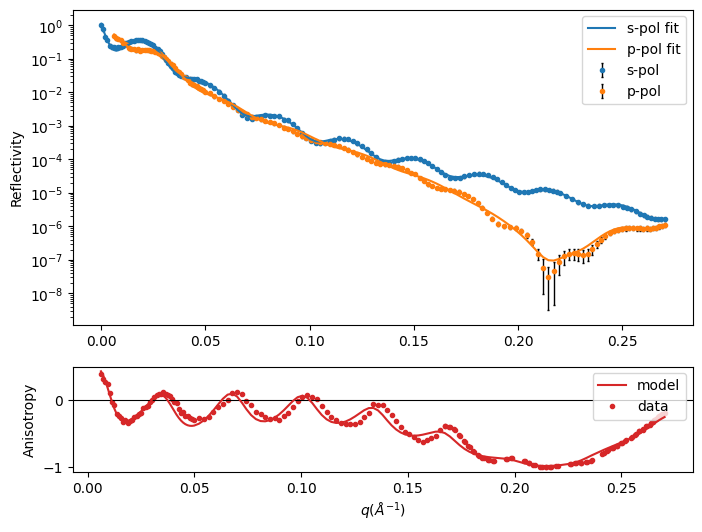

In [4]:
magic_angle = np.radians(54.73561031724)

for o in dft_constraint.objectives:
    if o.model.energy == 283.7:
        display(o.model.structure[1].sld.rotation.value * 180 / np.pi)
        display(o.model.structure[2].sld.rotation.value * 180 / np.pi)
        display(o.model.structure[3].sld.rotation.value * 180 / np.pi)
        # Constrain the rotation of the interface to be less than 54.73561031724 degrees
        # value to 0 degrees and remove lower bound on the thickness
        interface = o.model.structure[3]
        interface.sld.rotation.setp(value=54, bounds=(0, magic_angle))
        interface.sld.density.setp(bounds=(.5, 1.8))
        interface.thick.setp(value=0)
        interface.rough.setp(value=19)
        # Let's do the same for the surface interface
        surface = o.model.structure[1]
        surface.sld.rotation.setp(value=54, bounds=(0, np.pi/2))
        surface.sld.density.setp(bounds=(.5, 1.8))
        # surface.thick.setp(value=0)
        # surface.rough.setp(value=19)
        simple_fitter = fit.CurveFitter(o)
        simple_fitter.fit(options={"worker":-1})
        o.plot()
        print(interface)
        print(surface)
        break


<Axes: xlabel='zed / $\\AA$', ylabel='Index of refraction'>

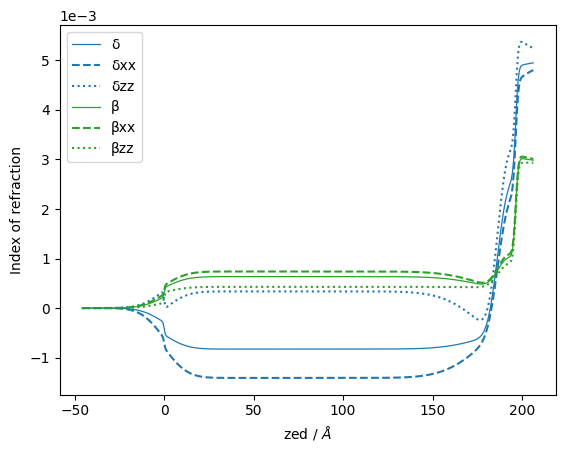

In [4]:
o.model.structure.plot()

In [5]:
print(o.model.structure)

________________________________________________________________________________
Structure: Monolayer_283.7
reverse structure: False
________________________________________________________________________________
Parameters: 'Vacuum_283.7' 
________________________________________________________________________________
Parameters: 'Vacuum_283.7_slab'
<Parameter:'Vacuum_283.7_thick', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rough', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rho', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_energy_offset', value=-0.0624303          , bounds=[-0.5, 0.5], constraint=<Parameter:'energy_offset', value=-0.0624303 +/- 0.0342, bounds=[-0.5, 0.5]>>
________________________________________________________________________________
Parameters: 'Surface_283.7'
________________________________________________________________________________
Parameters: 'Surface_283.7_slab'
<Parameter:'Surface_283.7_thick',

In [ ]:
test_fitter = fit.CurveFitter(dft_constraint)
test_fitter.fit(options={"worker":-1})

12.294784149504645: : 70it [15:36, 12.27s/it]

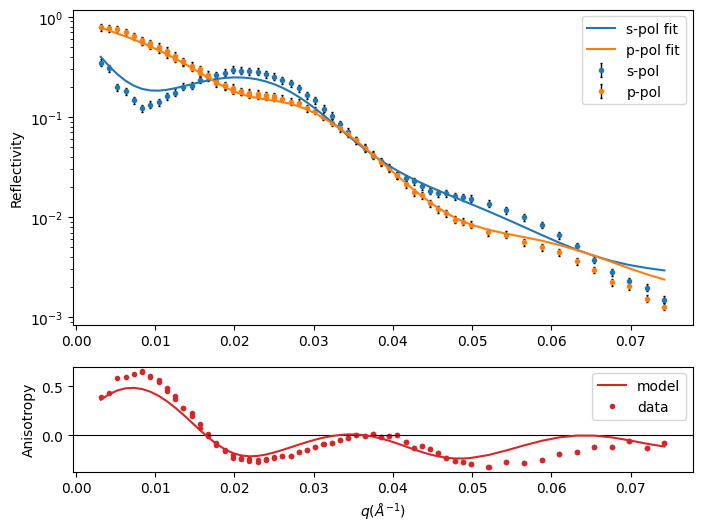

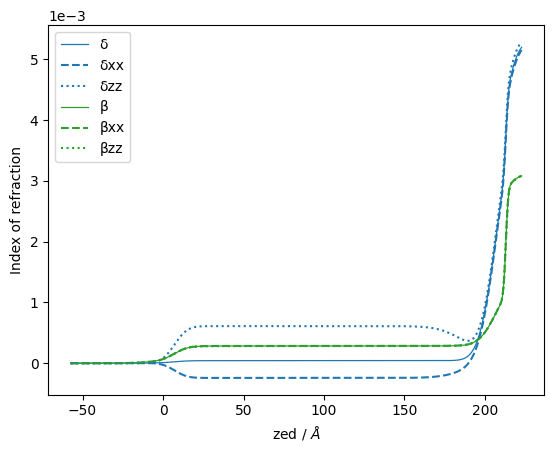

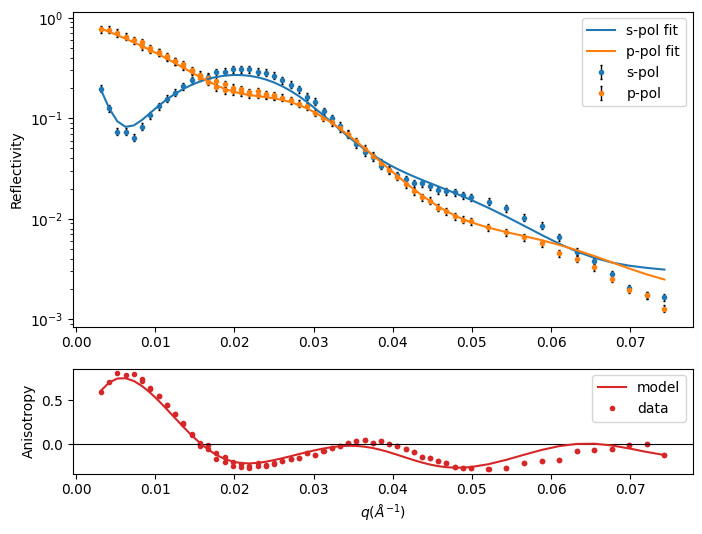

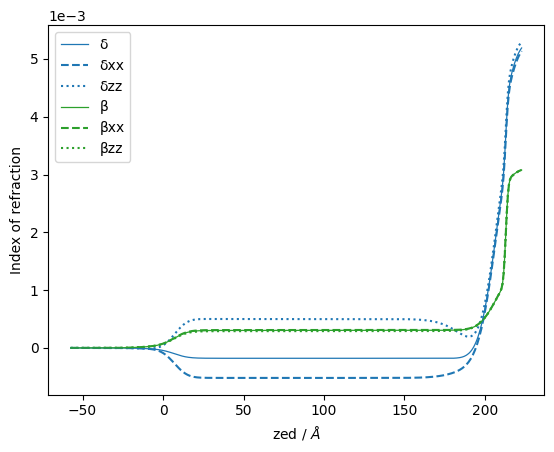

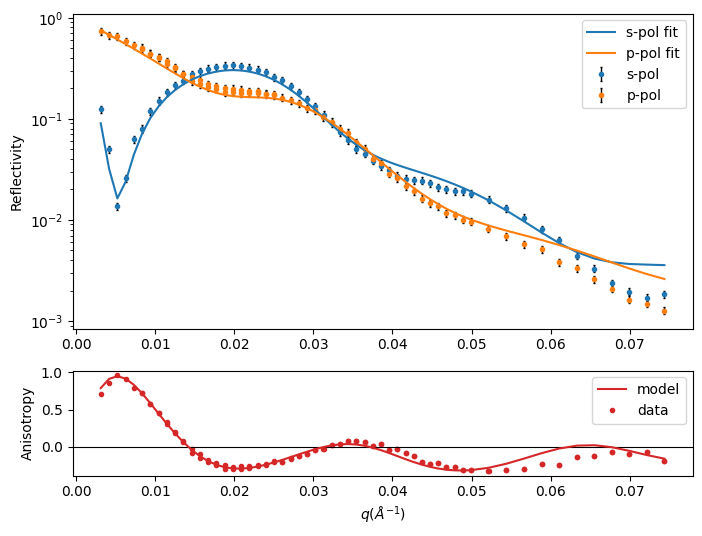

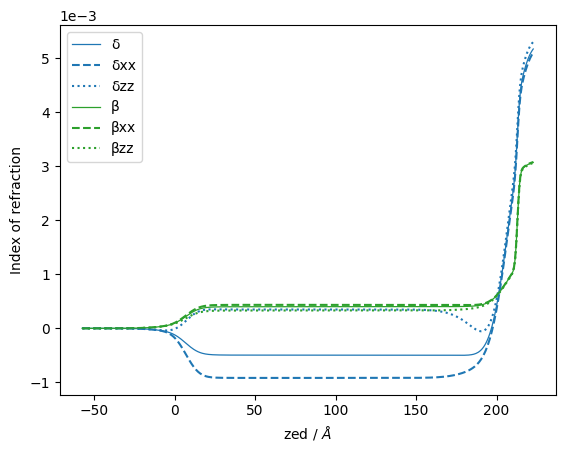

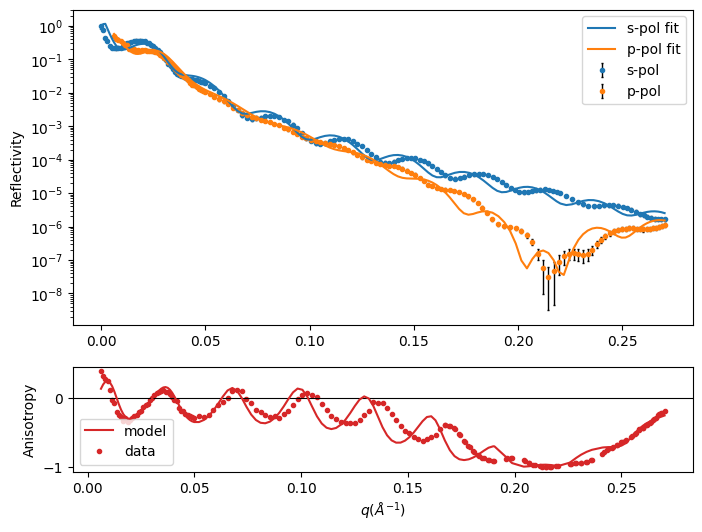

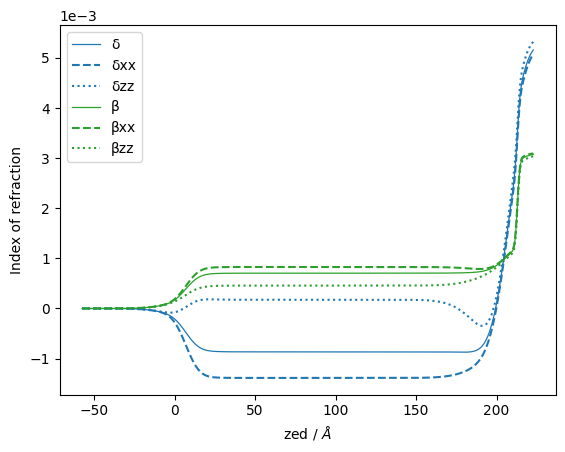

7.157663700119414 192.88473645839463 7.144105562929709
13.089369174809988 6.353264225585565 16.81191393780474
54.73561031724001 68.14230856157671 42.492953232206226


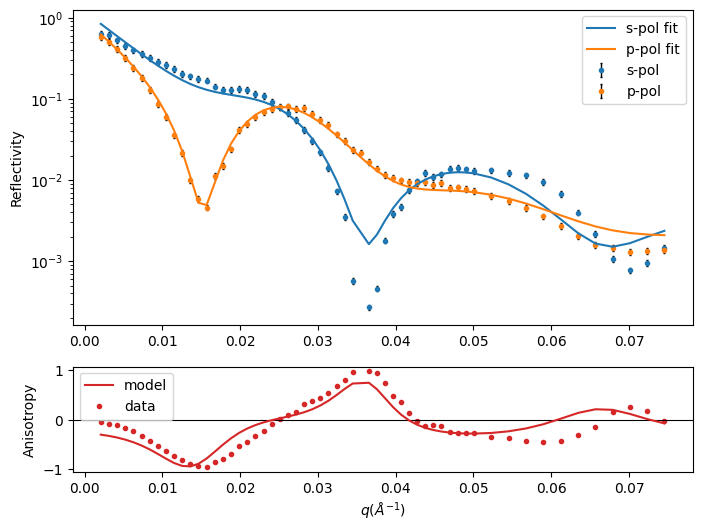

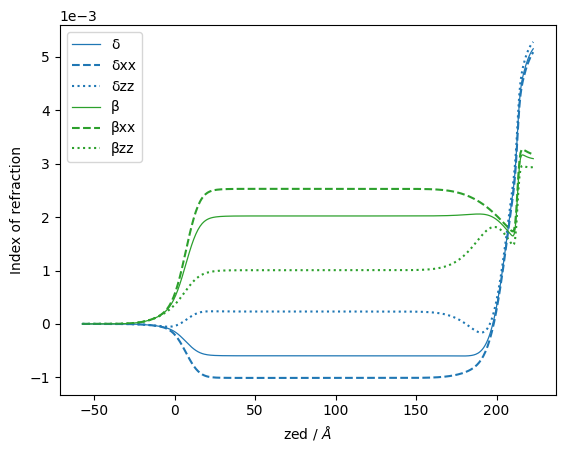

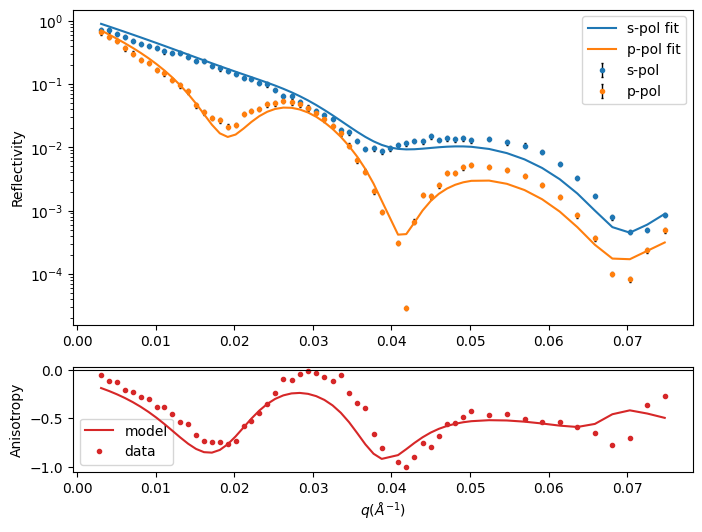

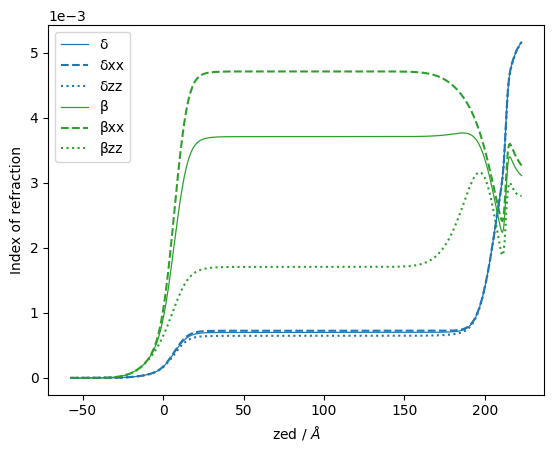

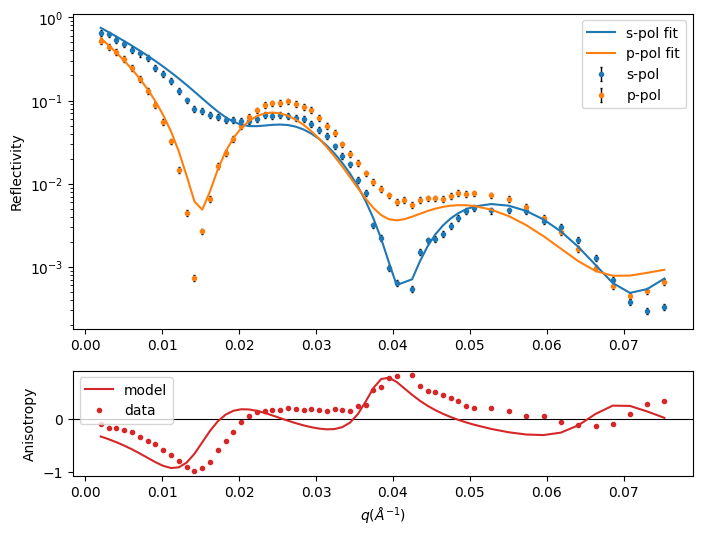

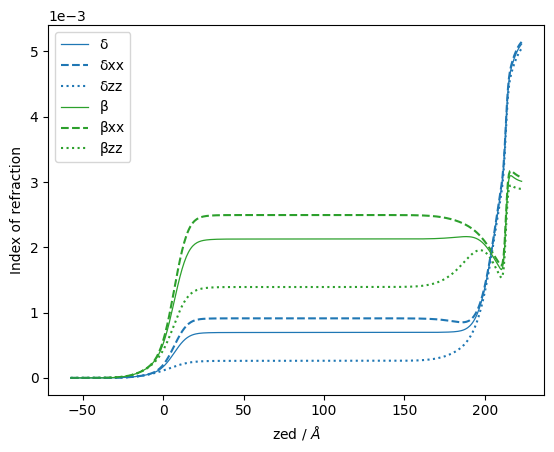

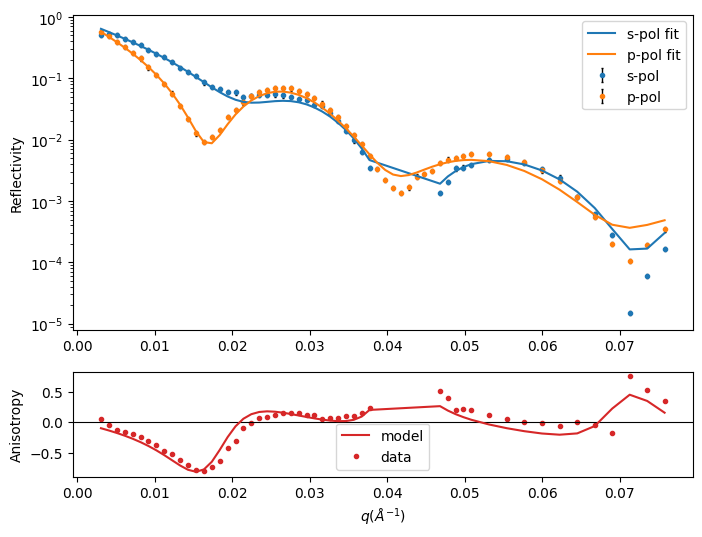

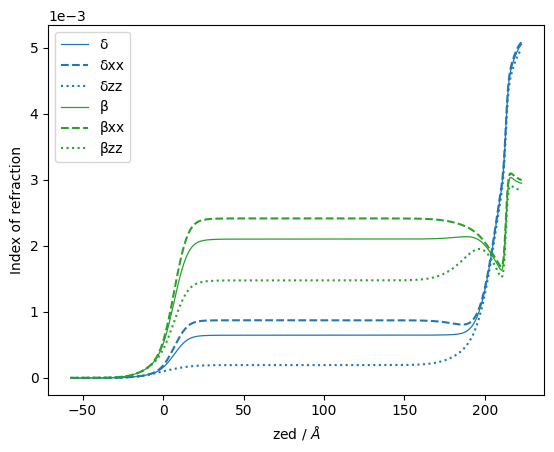

In [ ]:
import matplotlib.pyplot as plt

for o in test_fitter.objective.objectives:
    if o.model.energy >= 283:
        o.plot()
        plt.show()
        o.model.structure.plot()
        plt.show()
        if o.model.energy == 283.7:
            print(
                o.model.structure[1].thick.value,
                o.model.structure[2].thick.value,
                o.model.structure[3].thick.value,
            )
            print(
                o.model.structure[1].rough.value,
                o.model.structure[2].rough.value,
                o.model.structure[3].rough.value,
            )
            print(
                o.model.structure[1].sld.rotation.value * 180 / np.pi,
                o.model.structure[2].sld.rotation.value * 180 / np.pi,
                o.model.structure[3].sld.rotation.value * 180 / np.pi,
            )

In [33]:
with open(models_root / "xrr/dft/dft_en_offset_new.pkl", "wb") as f:
    pickle.dump(test_fitter.objective, f)
